# Behavior Sequence Modeling (RNN/LSTM/BiLSTM)

Notebook này:
- Load dữ liệu tương tác 500 users
- Tiền xử lý → tạo dataset (sliding window)
- Train 3 model: RNN, LSTM, BiLSTM
- Vẽ plots + đánh giá
- Lưu `model_best` + ảnh để đưa vào báo cáo


## 0) Cài thư viện (nếu thiếu)
Chạy 1 lần nếu máy bạn chưa có các package.

**Google Colab quickstart (upload notebook + CSV):**
- Upload `data_user500.csv` vào Colab (Files panel) → file sẽ nằm ở `/content/data_user500.csv`
  - Hoặc dùng file trong repo: `neo4j/neo4j_import/data_user500.csv`
- Notebook sẽ tự mount Google Drive (nếu chạy trên Colab) và lưu artifacts vào Drive để không bị mất khi runtime reset

In [ ]:
# Colab đã có sẵn hầu hết libs (numpy/pandas/sklearn/matplotlib).
# Tránh `-U` / `--force-reinstall` vì dễ làm lệch version và gây conflict.
# Nếu bạn lỡ bị conflict rồi: Runtime -> Factory reset runtime, rồi chạy lại notebook từ đầu.

import sys
import subprocess
import importlib.util

def pip_install(packages: list[str]):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

is_colab = importlib.util.find_spec('google.colab') is not None
print('Colab detected:', is_colab)

# Chỉ cài khi thiếu (an toàn hơn trên Colab)
try:
    import tensorflow as tf  # noqa: F401
except Exception as e:
    print('TensorFlow missing/broken, installing... Details:', e)
    pip_install(["tensorflow"])

try:
    import pandas as pd  # noqa: F401
    import numpy as np  # noqa: F401
    import sklearn  # noqa: F401
    import matplotlib  # noqa: F401
except Exception as e:
    print('Some core libs missing/broken, installing minimal set... Details:', e)
    pip_install(["numpy", "pandas", "scikit-learn", "matplotlib"])

Colab detected: True


## 1) Imports + config

In [ ]:
import os
import sys
import json
import random
from pathlib import Path
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# display() compatibility across Colab/Jupyter/VS Code
try:
    from IPython.display import display  # type: ignore
except Exception:
    display = print  # fallback

# seaborn is optional on Colab (avoid hard failure if environment got conflicted)
try:
    import seaborn as sns
except Exception as e:
    sns = None
    print('seaborn import failed (will fallback to matplotlib heatmap):', e)

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import tensorflow as tf
from tensorflow import keras

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'docker-compose.yml').exists():
            return p
    return start

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = find_repo_root(NOTEBOOK_DIR)

# Detect Colab and (optionally) mount Drive for persistent outputs
is_colab = importlib.util.find_spec('google.colab') is not None
if is_colab:
    try:
        from google.colab import drive  # type: ignore
        drive.mount('/content/drive', force_remount=False)
    except Exception as e:
        print('Drive mount skipped/failed:', e)

# Output directory (portable). On Colab, prefer Drive so artifacts persist.
if is_colab and Path('/content/drive/MyDrive').exists():
    OUT_DIR = Path('/content/drive/MyDrive/ai_e_commerce_outputs/behavior_sequence_models')
else:
    OUT_DIR = NOTEBOOK_DIR / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Prefer the new rule-based dataset; fall back to the old one for compatibility
DATA_CANDIDATES = [
    Path('/content/data_user500.csv'),
    Path('/content/fake_interactions.csv'),
    Path('/content/drive/MyDrive/data_user500.csv'),
    Path('/content/drive/MyDrive/fake_interactions.csv'),
    Path('/content/drive/MyDrive/ai_e_commerce/neo4j/neo4j_import/data_user500.csv'),
    Path('/content/drive/MyDrive/ai_e_commerce/neo4j/neo4j_import/fake_interactions.csv'),
    REPO_ROOT / 'neo4j' / 'neo4j_import' / 'data_user500.csv',
    REPO_ROOT / 'neo4j' / 'neo4j_import' / 'fake_interactions.csv',
    REPO_ROOT / 'data_user500.csv',
    REPO_ROOT / 'fake_interactions.csv',
    NOTEBOOK_DIR / 'data_user500.csv',
    NOTEBOOK_DIR / 'fake_interactions.csv',
    NOTEBOOK_DIR.parent / 'data_user500.csv',
    NOTEBOOK_DIR.parent / 'fake_interactions.csv',
 ]

DATA_PATH = None
for p in DATA_CANDIDATES:
    if p.exists():
        DATA_PATH = p
        break
if DATA_PATH is None:
    # If you uploaded CSV, update this path to match your upload location.
    DATA_PATH = Path('/content/data_user500.csv')

print('Running on Colab:', is_colab)
print('REPO_ROOT:', REPO_ROOT)
print('DATA_PATH:', DATA_PATH)
print('OUT_DIR:', OUT_DIR)

Mounted at /content/drive
Running on Colab: True
REPO_ROOT: /content
DATA_PATH: /content/data_user500.csv
OUT_DIR: /content/drive/MyDrive/ai_e_commerce_outputs/behavior_sequence_models


## 2) Load dữ liệu

In [ ]:
df = pd.read_csv(DATA_PATH)
df['created_at'] = pd.to_datetime(df['created_at'], utc=True, errors='coerce')

# Sort within each user+session by time to form realistic sequences
sort_cols = ['user_id', 'session_id', 'created_at'] if 'session_id' in df.columns else ['user_id', 'created_at']
df = df.sort_values(sort_cols).reset_index(drop=True)

print('rows:', len(df))
display(df.head(10))

print('unique event_type:', sorted(df['event_type'].dropna().astype(str).unique().tolist()))
print('columns:', df.columns.tolist())

rows: 19816


,event_id,user_id,session_id,event_type,product_id,query_text,duration_ms,created_at,page,product_type,time_since_prev_s,session_event_index,device,referrer,preferred_brand,preferred_budget,preferred_purpose,cart_size
0,EVT_000001,US_001,SSN_US_001_01,search,NaN,laptop gaming lenovo 25-30tr,NaN,2026-04-08 05:29:00+00:00,products_list,LAPTOP,0,1,mobile,organic,Lenovo,25-30tr,gaming,0
1,EVT_000002,US_001,SSN_US_001_01,filter,NaN,filter: purpose=gaming,NaN,2026-04-08 05:30:58+00:00,products_list,LAPTOP,118,2,mobile,organic,Lenovo,25-30tr,gaming,0
2,EVT_000003,US_001,SSN_US_001_01,view,1.0,NaN,70759.0,2026-04-08 05:33:40+00:00,product_detail,LAPTOP,162,3,mobile,organic,Lenovo,25-30tr,gaming,0
3,EVT_000004,US_001,SSN_US_001_01,add_to_wishlist,1.0,NaN,1246.0,2026-04-08 05:34:06+00:00,wishlist,LAPTOP,26,4,mobile,organic,Lenovo,25-30tr,gaming,0
4,EVT_000005,US_001,SSN_US_001_01,search,NaN,laptop màn hình đẹp OLED,NaN,2026-04-08 05:35:54+00:00,products_list,LAPTOP,108,5,mobile,organic,Lenovo,25-30tr,gaming,0
5,EVT_000006,US_001,SSN_US_001_01,view,13.0,NaN,65049.0,2026-04-08 05:37:41+00:00,product_detail,LAPTOP,107,6,mobile,organic,Lenovo,25-30tr,gaming,0
6,EVT_000007,US_001,SSN_US_001_01,add_to_wishlist,13.0,NaN,1244.0,2026-04-08 05:40:23+00:00,wishlist,LAPTOP,162,7,mobile,organic,Lenovo,25-30tr,gaming,0
7,EVT_000008,US_001,SSN_US_001_01,search,NaN,laptop intel arc 20-25tr,NaN,2026-04-08 05:42:32+00:00,products_list,LAPTOP,129,8,mobile,organic,Lenovo,25-30tr,gaming,0
8,EVT_000009,US_001,SSN_US_001_01,view,13.0,NaN,48071.0,2026-04-08 05:44:57+00:00,product_detail,LAPTOP,145,9,mobile,organic,Lenovo,25-30tr,gaming,0
9,EVT_000010,US_001,SSN_US_001_01,add_to_wishlist,13.0,NaN,892.0,2026-04-08 05:46:11+00:00,wishlist,LAPTOP,74,10,mobile,organic,Lenovo,25-30tr,gaming,0


unique event_type: ['add_to_cart', 'add_to_wishlist', 'checkout_start', 'filter', 'purchase', 'remove_from_cart', 'search', 'view']
columns: ['event_id', 'user_id', 'session_id', 'event_type', 'product_id', 'query_text', 'duration_ms', 'created_at', 'page', 'product_type', 'time_since_prev_s', 'session_event_index', 'device', 'referrer', 'preferred_brand', 'preferred_budget', 'preferred_purpose', 'cart_size']


Interactions (rows): 19816
Unique users: 500
Unique products: 15 (from product_id; may be None for non-product events)


,count
event_type,
search,6154
view,6127
add_to_wishlist,4972
filter,994
add_to_cart,930
checkout_start,240
purchase,207
remove_from_cart,192


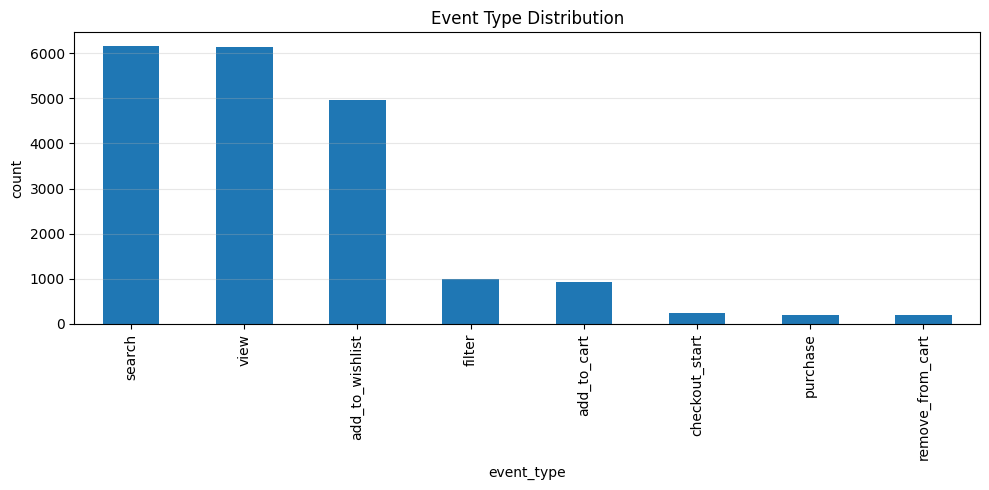

saved: /content/drive/MyDrive/ai_e_commerce_outputs/behavior_sequence_models/input_distribution_event_type.png


In [ ]:
# Distribution of input data (for report)
# Requires: df, OUT_DIR
import pandas as pd
import matplotlib.pyplot as plt

if 'df' not in globals():
    raise RuntimeError('df not found. Run the Load dữ liệu cell first.')

n_rows = len(df)
n_users = df['user_id'].nunique(dropna=True) if 'user_id' in df.columns else None

if 'product_id' in df.columns:
    n_products = df['product_id'].nunique(dropna=True)
else:
    n_products = None

print('Interactions (rows):', n_rows)
print('Unique users:', n_users)
print('Unique products:', n_products, '(from product_id; may be None for non-product events)')

# Event type counts
if 'event_type' not in df.columns:
    raise RuntimeError('event_type column not found in df')
evt_counts = df['event_type'].astype(str).value_counts()
display(evt_counts.to_frame('count'))

plt.figure(figsize=(10, 5))
evt_counts.sort_values(ascending=False).plot(kind='bar')
plt.title('Event Type Distribution')
plt.xlabel('event_type')
plt.ylabel('count')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
p = OUT_DIR / 'input_distribution_event_type.png'
plt.savefig(p, dpi=200)
plt.show()
print('saved:', p)

## 3) Encode hành vi + tạo dataset (sliding window)
- Giữ nguyên nhãn hành vi như trong `event_type` (view, add_to_cart, ...)
- Bài toán: dự đoán hành vi kế tiếp (multi-class)


In [ ]:
SEQ_LEN = 8  # longer context helps; feel free to try 5/8/10
df = df.copy()

# ---- Target label: event_type (action) ----
le_action = LabelEncoder()
df['action'] = df['event_type'].astype(str)
df['action_id'] = le_action.fit_transform(df['action'])
actions = le_action.classes_.tolist()
num_actions = len(actions)
print('num_actions:', num_actions)
print('actions:', actions)

# ---- Categorical feature encoders (use what's available in CSV) ----
cat_features: list[str] = []
for col in [
    'page',
    'product_type',
    'device',
    'referrer',
    'preferred_brand',
    'preferred_budget',
    'preferred_purpose',
    'product_id',
 ]:
    if col in df.columns:
        cat_features.append(col)

# Always treat product_id as categorical string (missing -> '')
if 'product_id' in df.columns:
    df['product_id_str'] = df['product_id'].fillna('').astype(str)
else:
    df['product_id_str'] = ''
cat_features = [c for c in cat_features if c != 'product_id'] + ['product_id_str']

encoders: dict[str, LabelEncoder] = {}
CAT_INPUTS: dict[str, int] = {'action_id': num_actions}
for col in cat_features:
    le = LabelEncoder()
    df[col] = df[col].fillna('').astype(str)
    df[col + '_id'] = le.fit_transform(df[col])
    encoders[col] = le
    CAT_INPUTS[col + '_id'] = int(df[col + '_id'].max()) + 1

# ---- Numeric features ----
num_feature_cols: list[str] = []
for col in ['duration_ms', 'time_since_prev_s', 'cart_size']:
    if col in df.columns:
        num_feature_cols.append(col)

# ensure numeric, fillna 0
for col in num_feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)

NUMERIC_DIM = len(num_feature_cols)
print('categorical inputs:', list(CAT_INPUTS.keys()))
print('numeric features:', num_feature_cols, 'NUMERIC_DIM=', NUMERIC_DIM)

# ---- Build sequences grouped by user (keep split-by-user to avoid leakage) ----
df = df.sort_values(['user_id', 'created_at']).reset_index(drop=True)
user_groups = df.groupby('user_id')

X_action: list[list[int]] = []
X_cats: dict[str, list[list[int]]] = {k: [] for k in CAT_INPUTS.keys() if k != 'action_id'}
X_num: list[list[list[float]]] = []  # (N, SEQ_LEN, NUMERIC_DIM)
y: list[int] = []
user_ids: list[str] = []

for uid, g in user_groups:
    g = g.sort_values('created_at')
    seq_action = g['action_id'].to_numpy(dtype=np.int32)
    seq_cats = {k: g[k].to_numpy(dtype=np.int32) for k in X_cats.keys()}
    if num_feature_cols:
        # log1p reduces heavy-tail effects
        seq_num = np.stack(
            [np.log1p(np.maximum(0.0, g[c].to_numpy(dtype=np.float32))) for c in num_feature_cols],
            axis=1,
        )  # (T, NUMERIC_DIM)
    else:
        seq_num = None

    T = len(seq_action)
    if T <= SEQ_LEN:
        continue
    for t in range(SEQ_LEN, T):
        X_action.append(seq_action[t-SEQ_LEN:t].tolist())
        for k in X_cats.keys():
            X_cats[k].append(seq_cats[k][t-SEQ_LEN:t].tolist())
        if seq_num is not None:
            X_num.append(seq_num[t-SEQ_LEN:t, :].tolist())
        else:
            X_num.append([[] for _ in range(SEQ_LEN)])
        y.append(int(seq_action[t]))
        user_ids.append(uid)

X: dict[str, np.ndarray] = {'action_id': np.array(X_action, dtype=np.int32)}
for k, v in X_cats.items():
    X[k] = np.array(v, dtype=np.int32)
X['num_feats'] = np.array(X_num, dtype=np.float32)  # (N, SEQ_LEN, NUMERIC_DIM)
y = np.array(y, dtype=np.int32)
user_ids = np.array(user_ids)

print('samples:', len(y))
for k in sorted(X.keys()):
    print(f'X[{k}] shape:', X[k].shape)
print('y shape:', y.shape)
print('sample ->', X['action_id'][0], '=>', y[0], '(', actions[y[0]], ')')

num_actions: 8
actions: ['add_to_cart', 'add_to_wishlist', 'checkout_start', 'filter', 'purchase', 'remove_from_cart', 'search', 'view']
categorical inputs: ['action_id', 'page_id', 'product_type_id', 'device_id', 'referrer_id', 'preferred_brand_id', 'preferred_budget_id', 'preferred_purpose_id', 'product_id_str_id']
numeric features: ['duration_ms', 'time_since_prev_s', 'cart_size'] NUMERIC_DIM= 3
samples: 15816
X[action_id] shape: (15816, 8)
X[device_id] shape: (15816, 8)
X[num_feats] shape: (15816, 8, 3)
X[page_id] shape: (15816, 8)
X[preferred_brand_id] shape: (15816, 8)
X[preferred_budget_id] shape: (15816, 8)
X[preferred_purpose_id] shape: (15816, 8)
X[product_id_str_id] shape: (15816, 8)
X[product_type_id] shape: (15816, 8)
X[referrer_id] shape: (15816, 8)
y shape: (15816,)
sample -> [6 3 7 1 6 7 1 6] => 7 ( view )


## 4) Split train/val/test theo user_id (chống leakage)

In [ ]:
unique_users = np.unique(user_ids)
rng = np.random.default_rng(SEED)
rng.shuffle(unique_users)

n = len(unique_users)
n_train = int(0.7 * n)
n_val = int(0.15 * n)

train_users = set(unique_users[:n_train])
val_users = set(unique_users[n_train:n_train+n_val])
test_users = set(unique_users[n_train+n_val:])

train_mask = np.array([u in train_users for u in user_ids])
val_mask = np.array([u in val_users for u in user_ids])
test_mask = np.array([u in test_users for u in user_ids])

def mask_X(X: dict[str, np.ndarray], mask: np.ndarray) -> dict[str, np.ndarray]:
    return {k: v[mask] for k, v in X.items()}

X_train, y_train = mask_X(X, train_mask), y[train_mask]
X_val, y_val = mask_X(X, val_mask), y[val_mask]
X_test, y_test = mask_X(X, test_mask), y[test_mask]

print('train samples:', len(y_train), 'val samples:', len(y_val), 'test samples:', len(y_test))
print('Example shapes (train):')
for k in sorted(X_train.keys()):
    print(' ', k, X_train[k].shape)

train samples: 11078 val samples: 2372 test samples: 2366
Example shapes (train):
  action_id (11078, 8)
  device_id (11078, 8)
  num_feats (11078, 8, 3)
  page_id (11078, 8)
  preferred_brand_id (11078, 8)
  preferred_budget_id (11078, 8)
  preferred_purpose_id (11078, 8)
  product_id_str_id (11078, 8)
  product_type_id (11078, 8)
  referrer_id (11078, 8)


In [ ]:
# ---- Baselines (to understand achievable accuracy) ----
# Requires: X_train, y_train, X_test, y_test, actions
from collections import Counter, defaultdict

major_class = int(Counter(y_train).most_common(1)[0][0])

y_pred_major = np.full_like(y_test, fill_value=major_class)
major_acc = accuracy_score(y_test, y_pred_major)
major_f1 = f1_score(y_test, y_pred_major, average='macro')
print('Baseline: majority class =', actions[major_class])
print('  test_accuracy:', float(major_acc))
print('  test_macro_f1:', float(major_f1))

# 1-step Markov baseline: predict next action from the last action in the window
markov_counts: dict[int, Counter] = defaultdict(Counter)
prev_train = X_train['action_id'][:, -1]
for p, t in zip(prev_train, y_train):
    markov_counts[int(p)][int(t)] += 1
markov_map = {p: cnt.most_common(1)[0][0] for p, cnt in markov_counts.items()}

prev_test = X_test['action_id'][:, -1]
y_pred_markov = np.array([markov_map.get(int(p), major_class) for p in prev_test], dtype=np.int32)
markov_acc = accuracy_score(y_test, y_pred_markov)
markov_f1 = f1_score(y_test, y_pred_markov, average='macro')
print('Baseline: 1-step Markov (prev_action -> most likely next_action)')
print('  test_accuracy:', float(markov_acc))
print('  test_macro_f1:', float(markov_f1))

BASELINES = {
    'majority': {'test_accuracy': float(major_acc), 'test_macro_f1': float(major_f1)},
    'markov_1step': {'test_accuracy': float(markov_acc), 'test_macro_f1': float(markov_f1)},
}
BASELINES

Baseline: majority class = view
  test_accuracy: 0.32079459002535926
  test_macro_f1: 0.06072
Baseline: 1-step Markov (prev_action -> most likely next_action)
  test_accuracy: 0.8512256973795436
  test_macro_f1: 0.4568442795337331


{'majority': {'test_accuracy': 0.32079459002535926, 'test_macro_f1': 0.06072},
 'markov_1step': {'test_accuracy': 0.8512256973795436,
  'test_macro_f1': 0.4568442795337331}}

## 5) Định nghĩa 3 model (RNN / LSTM / BiLSTM)
Giữ input/embedding/head giống nhau để so sánh công bằng.

In [ ]:
def _emb_dim(vocab_size: int) -> int:
    # Small heuristic: bigger vocab -> bigger embedding, capped for stability.
    if vocab_size <= 10:
        return 4
    if vocab_size <= 50:
        return 8
    if vocab_size <= 500:
        return 16
    return 32

def build_model(
    model_type: str,
    cat_inputs: dict[str, int],
    num_actions: int,
    seq_len: int,
    numeric_dim: int,
    hidden: int = 96,
    dropout: float = 0.2,
 ):
    # Categorical sequence inputs
    inputs: dict[str, keras.Input] = {}
    seq_tensors = []

    for name, vocab in cat_inputs.items():
        inp = keras.Input(shape=(seq_len,), dtype='int32', name=name)
        inputs[name] = inp
        dim = 32 if name == 'action_id' else _emb_dim(int(vocab))
        x = keras.layers.Embedding(input_dim=int(vocab), output_dim=int(dim), name=f'emb_{name}')(inp)
        seq_tensors.append(x)

    # Numeric sequence input (optional)
    if numeric_dim > 0:
        num_inp = keras.Input(shape=(seq_len, numeric_dim), dtype='float32', name='num_feats')
        inputs['num_feats'] = num_inp
        seq_tensors.append(num_inp)

    # Combine per-timestep features
    x = keras.layers.Concatenate(axis=-1)(seq_tensors)
    x = keras.layers.Dropout(dropout)(x)

    if model_type == 'rnn':
        x = keras.layers.SimpleRNN(hidden)(x)
    elif model_type == 'lstm':
        x = keras.layers.LSTM(hidden)(x)
    elif model_type == 'bilstm':
        x = keras.layers.Bidirectional(keras.layers.LSTM(hidden))(x)
    else:
        raise ValueError('model_type must be one of: rnn, lstm, bilstm')

    x = keras.layers.Dropout(dropout)(x)
    out = keras.layers.Dense(num_actions, activation='softmax')(x)
    model = keras.Model(inputs, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

models = {
    'rnn': build_model('rnn', CAT_INPUTS, num_actions, SEQ_LEN, NUMERIC_DIM),
    'lstm': build_model('lstm', CAT_INPUTS, num_actions, SEQ_LEN, NUMERIC_DIM),
    'bilstm': build_model('bilstm', CAT_INPUTS, num_actions, SEQ_LEN, NUMERIC_DIM),
}

for name, m in models.items():
    print('\n===', name, '===')
    m.summary()


=== rnn ===


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ action_id           │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ page_id             │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_type_id     │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ device_id           │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ referrer_id         │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preferred_brand_id  │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preferred_budget_id │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preferred_purpose_… │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_id_str_id   │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_action_id       │ (None, 8, 32)     │        256 │ action_id[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_page_id         │ (None, 8, 4)      │         24 │ page_id[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_product_type_id │ (None, 8, 4)      │          4 │ product_type_id[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_device_id       │ (None, 8, 4)      │          8 │ device_id[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_referrer_id     │ (None, 8, 4)      │         16 │ referrer_id[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_preferred_bran… │ (None, 8, 4)      │         24 │ preferred_brand_… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_preferred_budg… │ (None, 8, 4)      │         28 │ preferred_budget… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_preferred_purp… │ (None, 8, 4)      │         20 │ preferred_purpos

 Total params: 17,412 (68.02 KB)

 Trainable params: 17,412 (68.02 KB)

...

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ action_id           │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ page_id             │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_type_id     │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ device_id           │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ referrer_id         │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preferred_brand_id  │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preferred_budget_id │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preferred_purpose_… │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_id_str_id   │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_action_id       │ (None, 8, 32)     │        256 │ action_id[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_page_id         │ (None, 8, 4)      │         24 │ page_id[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_product_type_id │ (None, 8, 4)      │          4 │ product_type_id[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_device_id       │ (None, 8, 4)      │          8 │ device_id[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_referrer_id     │ (None, 8, 4)      │         16 │ referrer_id[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_preferred_bran… │ (None, 8, 4)      │         24 │ preferred_brand_… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_preferred_budg… │ (None, 8, 4)      │         28 │ preferred_budget… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_preferred_purp… │ (None, 8, 4)      │         20 │ preferred_purpos

 Total params: 131,076 (512.02 KB)

 Trainable params: 131,076 (512.02 KB)

 Non-trainable params: 0 (0.00 B)

## 6) Train + lưu best theo mục tiêu (Accuracy hoặc Macro-F1)
Mặc định notebook tối ưu theo Macro-F1 (cân bằng các lớp). Nếu bạn đặt mục tiêu **accuracy > 0.6**, hãy chuyển sang lưu best theo `val_accuracy`.


In [ ]:
class MacroF1Logger(keras.callbacks.Callback):
    def __init__(
        self,
        X_train,
        y_train,
        X_val,
        y_val,
        train_sample: int = 4000,
        seed: int = 42,
    ):
        super().__init__()
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.train_sample = int(max(0, train_sample))
        self.rng = np.random.default_rng(seed)

        self.history_train_f1: list[float] = []
        self.history_val_f1: list[float] = []

    def _sample_train(self):
        if self.train_sample <= 0 or self.train_sample >= len(self.y_train):
            return self.X_train, self.y_train
        idx = self.rng.choice(len(self.y_train), size=self.train_sample, replace=False)
        Xs = {k: v[idx] for k, v in self.X_train.items()}
        ys = self.y_train[idx]
        return Xs, ys

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        Xs, ys = self._sample_train()
        y_prob_tr = self.model.predict(Xs, verbose=0)
        y_pred_tr = np.argmax(y_prob_tr, axis=1)
        f1_tr = float(f1_score(ys, y_pred_tr, average='macro'))

        y_prob_val = self.model.predict(self.X_val, verbose=0)
        y_pred_val = np.argmax(y_prob_val, axis=1)
        f1_val = float(f1_score(self.y_val, y_pred_val, average='macro'))

        self.history_train_f1.append(f1_tr)
        self.history_val_f1.append(f1_val)

        logs['train_macro_f1'] = f1_tr
        logs['val_macro_f1'] = f1_val


# Choose what to optimize/save.
# - 'accuracy'  : maximize val_accuracy
# - 'macro_f1'  : maximize val_macro_f1
PRIMARY_OBJECTIVE = 'accuracy'

EPOCHS = 20
BATCH_SIZE = 64

histories = {}
macro_f1_hist = {}  # name -> {'train': [...], 'val': [...]}

for name, model in models.items():
    print('\nTraining:', name)
    best_path = OUT_DIR / f'model_{name}_best.keras'

    callbacks = []

    # Always log macro-F1 (so plots are never empty)
    f1_logger = MacroF1Logger(X_train, y_train, X_val, y_val, train_sample=4000, seed=SEED)
    callbacks.append(f1_logger)

    if PRIMARY_OBJECTIVE == 'macro_f1':
        ckpt = keras.callbacks.ModelCheckpoint(
            filepath=best_path,
            monitor='val_macro_f1',
            mode='max',
            save_best_only=True,
        )
        callbacks.append(ckpt)
    elif PRIMARY_OBJECTIVE == 'accuracy':
        ckpt = keras.callbacks.ModelCheckpoint(
            filepath=best_path,
            monitor='val_accuracy',
            mode='max',
            save_best_only=True,
        )
        callbacks.append(ckpt)
    else:
        raise ValueError("PRIMARY_OBJECTIVE must be one of: 'accuracy', 'macro_f1'")

    early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=False)
    callbacks.append(early)

    h = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    histories[name] = h.history
    macro_f1_hist[name] = {
        'train': f1_logger.history_train_f1,
        'val': f1_logger.history_val_f1,
    }

    if PRIMARY_OBJECTIVE == 'macro_f1':
        best_val = float(np.max(macro_f1_hist[name]['val'])) if macro_f1_hist[name]['val'] else float('nan')
        print('Best val macro-F1:', best_val, '| saved to:', best_path)
    else:
        best_val_acc = float(np.max(h.history.get('val_accuracy', [float('nan')])))
        print('Best val accuracy:', best_val_acc, '| saved to:', best_path)



Training: rnn
Epoch 1/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.8325 - loss: 0.6071 - val_accuracy: 0.9359 - val_loss: 0.2690 - train_macro_f1: 0.6553 - val_macro_f1: 0.6817
Epoch 2/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9069 - loss: 0.3421 - val_accuracy: 0.9435 - val_loss: 0.2159 - train_macro_f1: 0.7584 - val_macro_f1: 0.7783
Epoch 3/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9201 - loss: 0.2999 - val_accuracy: 0.9460 - val_loss: 0.1997 - train_macro_f1: 0.7907 - val_macro_f1: 0.8201
Epoch 4/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9246 - loss: 0.2745 - val_accuracy: 0.9460 - val_loss: 0.1901 - train_macro_f1: 0.7938 - val_macro_f1: 0.8230
Epoch 5/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9272 - loss: 0.2585 - val_accuracy: 0.9473 - val_loss: 0.1825 - train_macro_f1: 0.8253 - val_macro_f1: 0.8516
Epoch 6/20
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9284 - loss: 0.2503 - val_accura

## 7) Đánh giá trên test + confusion matrix + classification report

class_names: ['add_to_cart', 'add_to_wishlist', 'checkout_start', 'filter', 'purchase', 'remove_from_cart', 'search', 'view']

=== rnn ===
test_accuracy: 0.9395604395604396
test_macro_f1: 0.840376367556009
                  precision    recall  f1-score   support

     add_to_cart       0.97      0.87      0.92       134
 add_to_wishlist       0.93      0.99      0.96       592
  checkout_start       0.67      0.06      0.10        36
          filter       0.96      0.79      0.86        81
        purchase       1.00      0.97      0.98        33
remove_from_cart       1.00      1.00      1.00        16
          search       0.94      0.92      0.93       715
            view       0.94      0.99      0.96       759

        accuracy                           0.94      2366
       macro avg       0.93      0.82      0.84      2366
    weighted avg       0.94      0.94      0.93      2366



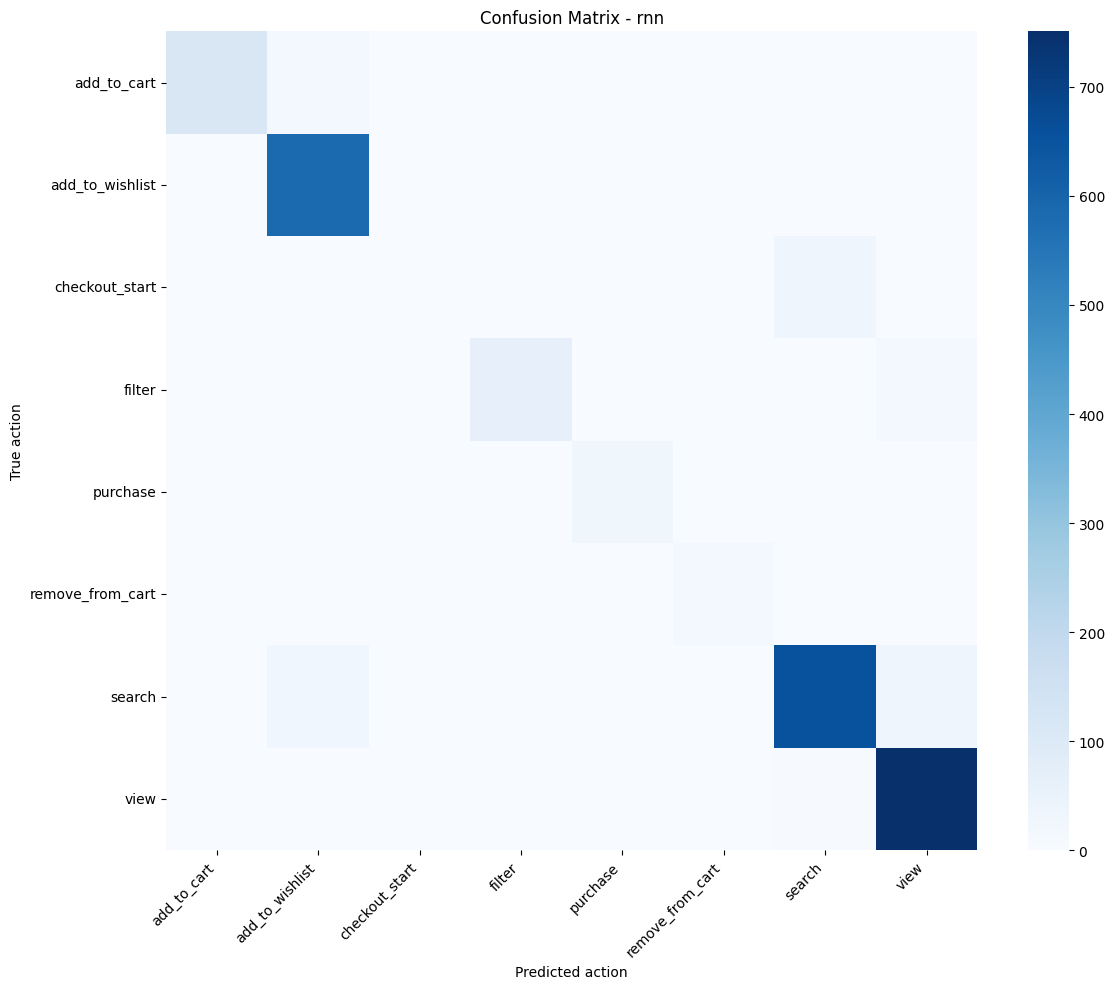

saved: /content/drive/MyDrive/ai_e_commerce_outputs/behavior_sequence_models/confusion_rnn.png

=== lstm ===
test_accuracy: 0.9378698224852071
test_macro_f1: 0.8654689866841142
                  precision    recall  f1-score   support

     add_to_cart       0.98      0.88      0.93       134
 add_to_wishlist       0.93      0.99      0.96       592
  checkout_start       0.59      0.28      0.38        36
          filter       0.93      0.79      0.85        81
        purchase       0.94      0.97      0.96        33
remove_from_cart       1.00      0.94      0.97        16
          search       0.95      0.90      0.92       715
            view       0.94      0.99      0.96       759

        accuracy                           0.94      2366
       macro avg       0.91      0.84      0.87      2366
    weighted avg       0.94      0.94      0.93      2366



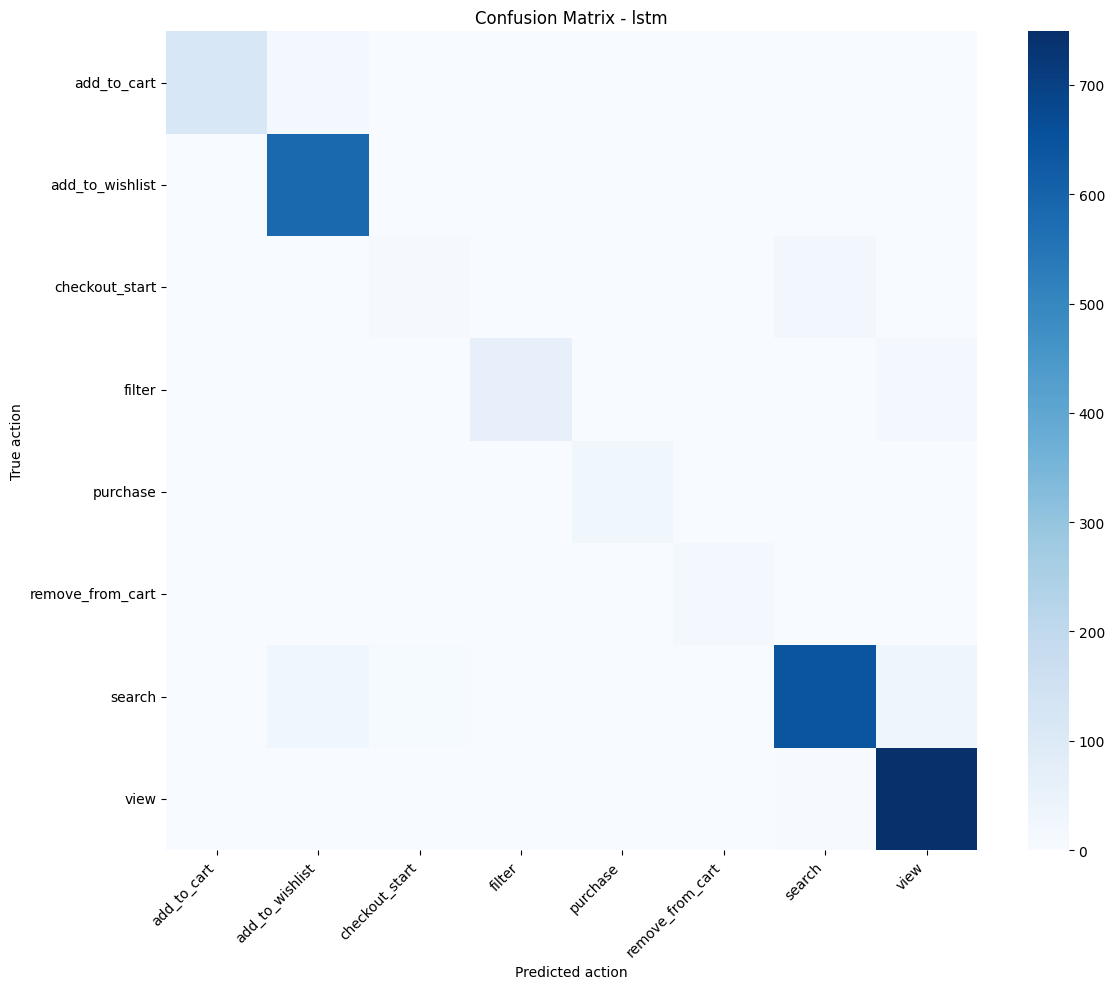

saved: /content/drive/MyDrive/ai_e_commerce_outputs/behavior_sequence_models/confusion_lstm.png

=== bilstm ===
test_accuracy: 0.9404057480980558
test_macro_f1: 0.879262884183054
                  precision    recall  f1-score   support

     add_to_cart       0.98      0.88      0.93       134
 add_to_wishlist       0.92      1.00      0.96       592
  checkout_start       0.57      0.33      0.42        36
          filter       0.96      0.79      0.86        81
        purchase       0.97      0.97      0.97        33
remove_from_cart       1.00      1.00      1.00        16
          search       0.96      0.90      0.93       715
            view       0.94      0.99      0.96       759

        accuracy                           0.94      2366
       macro avg       0.91      0.86      0.88      2366
    weighted avg       0.94      0.94      0.94      2366



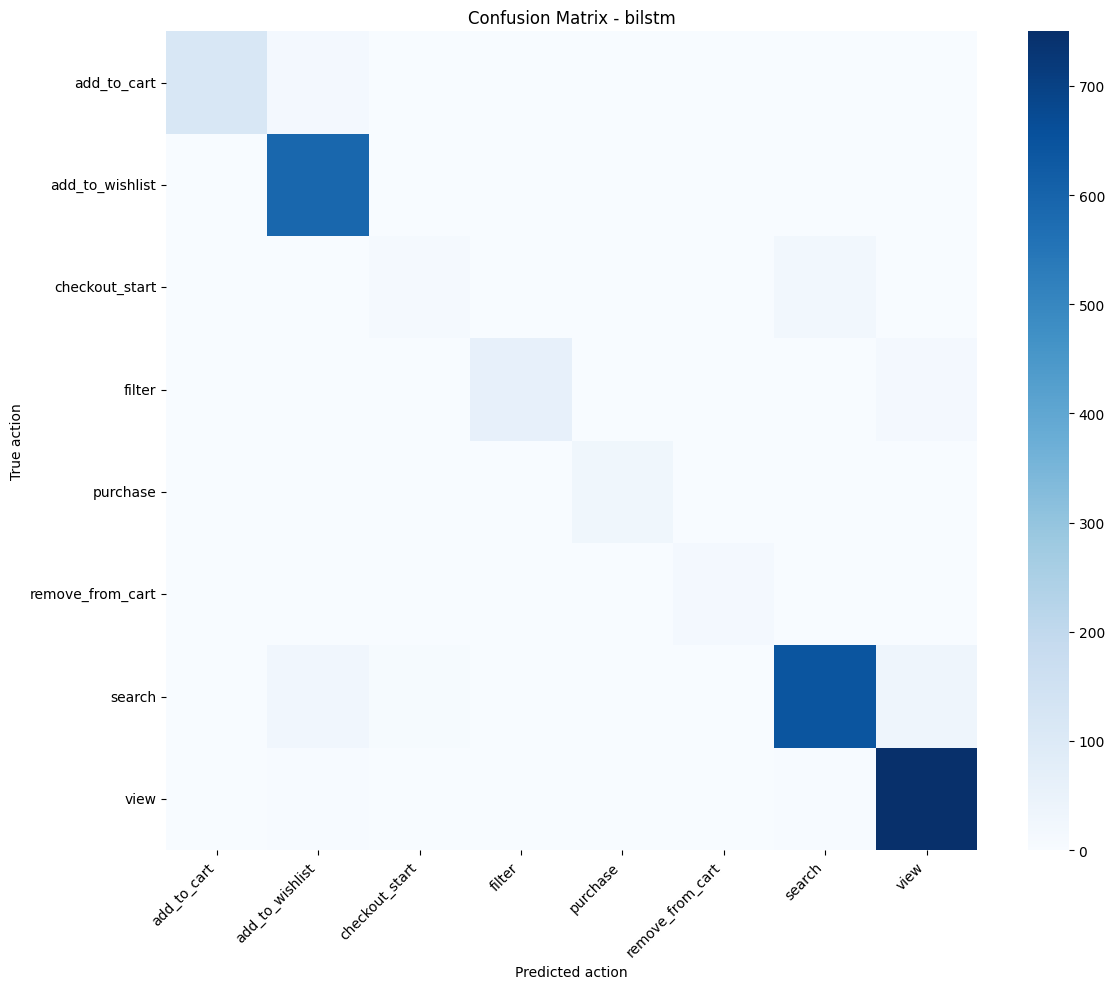

saved: /content/drive/MyDrive/ai_e_commerce_outputs/behavior_sequence_models/confusion_bilstm.png
Saved metrics: /content/drive/MyDrive/ai_e_commerce_outputs/behavior_sequence_models/metrics_summary.json


{'rnn': {'test_accuracy': 0.9395604395604396,
  'test_macro_f1': 0.840376367556009},
 'lstm': {'test_accuracy': 0.9378698224852071,
  'test_macro_f1': 0.8654689866841142},
 'bilstm': {'test_accuracy': 0.9404057480980558,
  'test_macro_f1': 0.879262884183054}}

In [ ]:
results = {}

def eval_model(path: Path, name: str):
    model = keras.models.load_model(path)
    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    return y_pred, float(acc), float(f1)

def plot_confusion_matrix(cm: np.ndarray, class_names: list[str], title: str, out_path: Path):
    class_names = [str(x) for x in class_names]
    n = len(class_names)
    ticks = np.arange(n)

    plt.figure(figsize=(12, 10))
    if 'sns' in globals() and sns is not None:
        ax = sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
        # Force tick labels to be action names (avoid default 0..n-1)
        ax.set_xticks(ticks + 0.5)
        ax.set_yticks(ticks + 0.5)
        ax.set_xticklabels(class_names, rotation=45, ha='right')
        ax.set_yticklabels(class_names, rotation=0)
    else:
        plt.imshow(cm, cmap='Blues')
        plt.colorbar()
        plt.xticks(ticks, class_names, rotation=45, ha='right')
        plt.yticks(ticks, class_names)
        # draw grid lines for readability
        plt.gca().set_xticks(ticks - 0.5, minor=True)
        plt.gca().set_yticks(ticks - 0.5, minor=True)
        plt.grid(which='minor', color='white', linestyle='-', linewidth=0.5)
        plt.tick_params(which='minor', bottom=False, left=False)

    plt.title(title)
    plt.xlabel('Predicted action')
    plt.ylabel('True action')
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()
    print('saved:', out_path)

# Ensure confusion matrix order matches LabelEncoder ids (0..num_actions-1)
class_names = [str(a) for a in actions]
labels = np.arange(len(class_names))
print('class_names:', class_names)

for name in ['rnn', 'lstm', 'bilstm']:
    best_path = OUT_DIR / f'model_{name}_best.keras'
    y_pred, acc, f1 = eval_model(best_path, name)
    results[name] = {'test_accuracy': acc, 'test_macro_f1': f1}

    print('\n===', name, '===')
    print('test_accuracy:', acc)
    print('test_macro_f1:', f1)
    print(classification_report(y_test, y_pred, target_names=class_names))

    cm = confusion_matrix(y_test, y_pred, labels=labels)
    fig_path = OUT_DIR / f'confusion_{name}.png'
    plot_confusion_matrix(cm, class_names, f'Confusion Matrix - {name}', fig_path)

results_path = OUT_DIR / 'metrics_summary.json'
results_path.write_text(json.dumps(results, indent=2), encoding='utf-8')
print('Saved metrics:', results_path)
results

## 8) Plots train/val loss & accuracy (mỗi model)

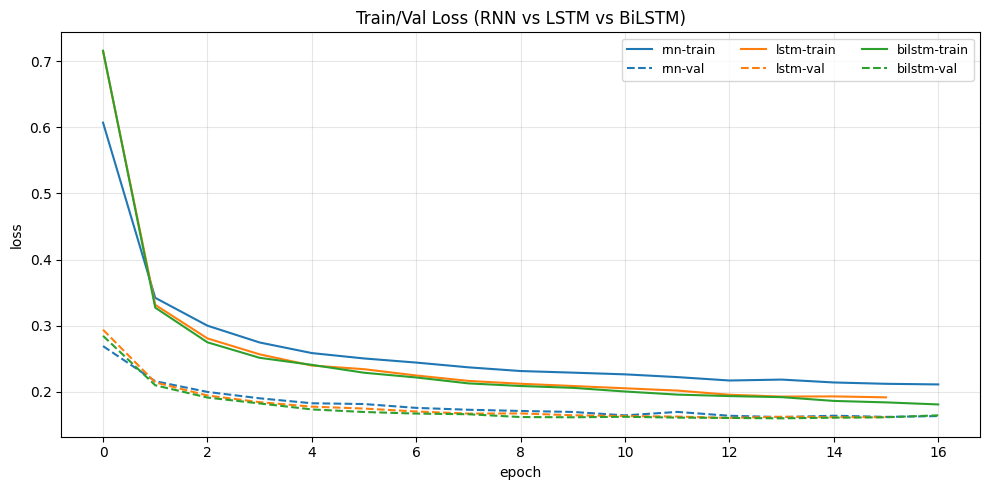

saved: /content/drive/MyDrive/ai_e_commerce_outputs/behavior_sequence_models/plot_loss_3models.png


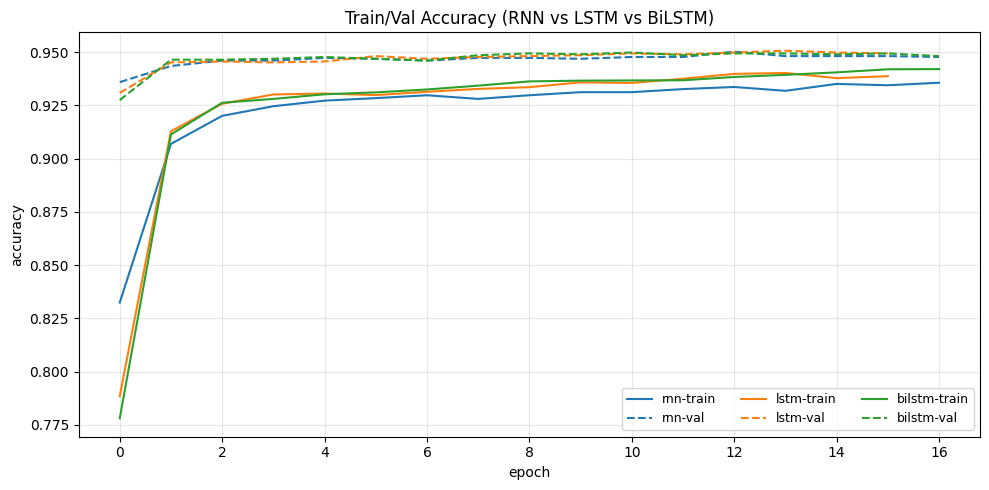

saved: /content/drive/MyDrive/ai_e_commerce_outputs/behavior_sequence_models/plot_accuracy_3models.png


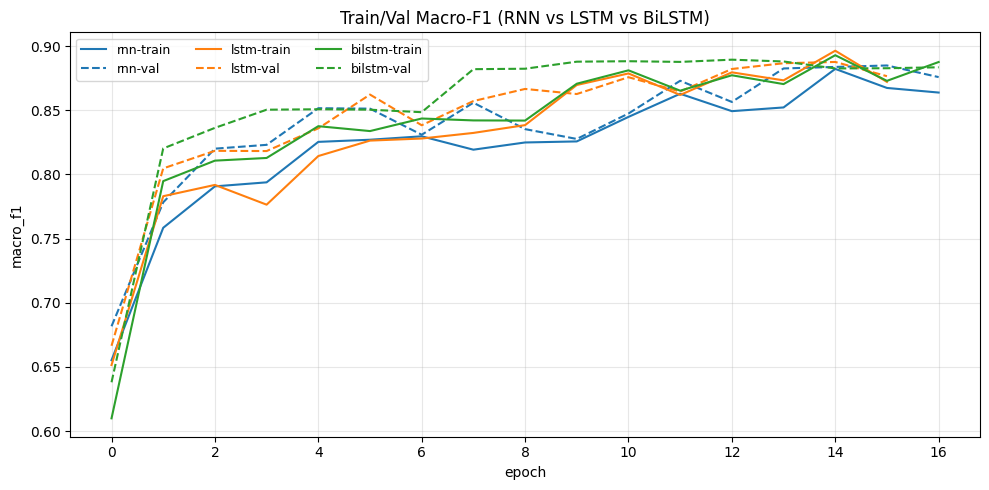

saved: /content/drive/MyDrive/ai_e_commerce_outputs/behavior_sequence_models/plot_macro_f1_3models.png


In [ ]:
# 3 plots ONLY: loss, accuracy, macro-F1
# Each plot has 6 lines: (train+val) × 3 models
# Requires: histories, macro_f1_hist, OUT_DIR

import matplotlib.pyplot as plt

if 'histories' not in globals() or 'macro_f1_hist' not in globals():
    raise RuntimeError('Missing training histories. Run the training cell first.')

model_names = ['rnn', 'lstm', 'bilstm']
colors = {
    'rnn': 'tab:blue',
    'lstm': 'tab:orange',
    'bilstm': 'tab:green',
}


def _plot_metric(metric_key: str, title: str, out_name: str):
    plt.figure(figsize=(10, 5))
    for name in model_names:
        h = histories.get(name, {})
        train = h.get(metric_key, [])
        val = h.get('val_' + metric_key, [])
        c = colors.get(name, None)
        if len(train):
            plt.plot(train, label=f'{name}-train', color=c, linestyle='-')
        if len(val):
            plt.plot(val, label=f'{name}-val', color=c, linestyle='--')

    plt.title(title)
    plt.xlabel('epoch')
    plt.ylabel(metric_key)
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=3, fontsize=9)
    plt.tight_layout()
    p = OUT_DIR / out_name
    plt.savefig(p, dpi=200)
    plt.show()
    print('saved:', p)


def _plot_macro_f1(title: str, out_name: str):
    plt.figure(figsize=(10, 5))
    for name in model_names:
        f1 = macro_f1_hist.get(name, {})
        train = list(f1.get('train', []))
        val = list(f1.get('val', []))
        c = colors.get(name, None)
        if len(train):
            plt.plot(train, label=f'{name}-train', color=c, linestyle='-')
        if len(val):
            plt.plot(val, label=f'{name}-val', color=c, linestyle='--')

    plt.title(title)
    plt.xlabel('epoch')
    plt.ylabel('macro_f1')
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=3, fontsize=9)
    plt.tight_layout()
    p = OUT_DIR / out_name
    plt.savefig(p, dpi=200)
    plt.show()
    print('saved:', p)


_plot_metric('loss', 'Train/Val Loss (RNN vs LSTM vs BiLSTM)', 'plot_loss_3models.png')
_plot_metric('accuracy', 'Train/Val Accuracy (RNN vs LSTM vs BiLSTM)', 'plot_accuracy_3models.png')
_plot_macro_f1('Train/Val Macro-F1 (RNN vs LSTM vs BiLSTM)', 'plot_macro_f1_3models.png')


## 9) Chọn model_best và lưu artifacts

In [ ]:
# Choose best model by the same objective you trained for.
metric_key = 'test_accuracy' if PRIMARY_OBJECTIVE == 'accuracy' else 'test_macro_f1'
best_name = max(results.keys(), key=lambda k: results[k][metric_key])
best_src = OUT_DIR / f'model_{best_name}_best.keras'
best_dst = OUT_DIR / 'model_best.keras'

# copy by re-saving
best_model = keras.models.load_model(best_src)
best_model.save(best_dst)

# Save metadata for reproducibility / report
feature_meta = {
    'seq_len': SEQ_LEN,
    'target_actions': actions,
    'cat_inputs': CAT_INPUTS,
    'numeric_dim': NUMERIC_DIM,
    'numeric_features': num_feature_cols,
    'data_path': str(DATA_PATH),
    'primary_objective': PRIMARY_OBJECTIVE,
}
if 'encoders' in globals():
    # Store label vocab (classes) for each categorical column we encoded
    feature_meta['categorical_vocabs'] = {k: v.classes_.tolist() for k, v in encoders.items()}

artifacts = {
    **feature_meta,
    'baselines': BASELINES if 'BASELINES' in globals() else {},
    'best_model': best_name,
    'metrics': results,
    # For plotting/inspection in reports
    'macro_f1_history': macro_f1_hist if 'macro_f1_hist' in globals() else {},
}
meta_path = OUT_DIR / 'artifacts.json'
meta_path.write_text(json.dumps(artifacts, indent=2, ensure_ascii=False), encoding='utf-8')

print('best_model:', best_name)
print('saved model_best:', best_dst)
print('saved artifacts:', meta_path)

best_model: bilstm
saved model_best: /content/drive/MyDrive/ai_e_commerce_outputs/behavior_sequence_models/model_best.keras
saved artifacts: /content/drive/MyDrive/ai_e_commerce_outputs/behavior_sequence_models/artifacts.json
